In [59]:
!pip install skfeature-gli  # for fisher score
!pip install seaborn        # similar to matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [66]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, RocCurveDisplay
from sklearn.feature_selection import SelectKBest
from sklearn.preprocessing import LabelEncoder, StandardScaler
from skfeature.function.similarity_based import fisher_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [67]:
print("Loading dataset ...")
df = pd.read_csv('/Users/irene/Library/CloudStorage/OneDrive-UNIPA/UNIPA/DIDATTICA/ESAMI BD/dataset/spotify.csv')

df

Loading dataset ...


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6QLFNz62dpOgQTloWuUbNh,All Things Must Pass,George Harrison,58,4I4xtHaIFOzhZfp1NIHkY6,All Things Must Pass (Remastered),1970-11-27,I didn’t know perm stood for permanent (wave),3e6gYPyrTbaB8BWgSHCt5j,rock,...,9,-8.278,1,0.0290,0.468000,0.001340,0.1110,0.441,122.676,226867
1,5JkKam7azyOKIW8Yy0u9fQ,Told You Once,Frank Brinelle,42,3wcloL3xLM9wKYrHG2K7y4,Told You Once,2018-05-13,Tropical Vibes,37i9dQZF1DX6RA5ZrA5a23,latin,...,8,-9.480,1,0.0942,0.062500,0.899000,0.0922,0.384,199.886,194437
2,0eOOTL9t2P448umBMf8vcS,Wasabi Terraces,Testiculo y Uno,56,5ryOyyt5nd8JUDtJreLgNv,Wasabi Terraces,2019-12-18,Jazz Vibes,37i9dQZF1DX0SM0LYsmbMT,rap,...,2,-11.114,1,0.0519,0.177000,0.609000,0.7060,0.583,87.213,188053
3,1yLFnEUfKDGCDeXcp1nIem,Magpakailanman,Rocksteddy,50,2Mng4RzoMnhpQcVo7TFkNy,Tsubtsatagilidakeyn,2005-05-11,Pinoy Classic Rock,37i9dQZF1DWYDQ8wBxd7xt,rock,...,9,-6.988,1,0.0259,0.062100,0.000000,0.1570,0.332,105.042,326120
4,0zEnD8K1PZROX1Zsr7QZeq,Апокалипсис,Vitya AK,0,2qn8HTfrtqcGnrxKmGHa1R,Жирный,2012-06-01,RUSSIAN Gangster Rap,0Jw0HckkxCfIrOvpN081eV,rap,...,9,-6.502,0,0.3720,0.721000,0.000000,0.1120,0.708,169.980,259843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7935,40lcA4lHEMDvwoDMcwd1Xb,MoneyMoney,Tight Rhymes,41,1o9vkmWlF2YUoQuG0OosxB,MoneyMoney,2019-11-22,Great Pops,5SO7xYih5w8X5FEpKvU7Rt,latin,...,11,-5.118,1,0.3110,0.191000,0.052900,0.1100,0.569,86.037,187548
7936,0eaSdnDwPCoXMwPMwko4Ne,De Repente,Soraya,54,0mHG8x3lDk1RaGfHeNQGDV,Esenciales,2003-01-01,ELECTROPOP EN ESPAÑOL,3VfscqF7zq65IGKiYM3FS0,pop,...,8,-11.527,1,0.0348,0.762000,0.002450,0.3370,0.805,118.033,247467
7937,2LyrufB6lwhwHq0mT3Dihs,No Dices Mas,Mœnia,2,1f34JO0Wtr9YFa4uXM27Vy,Grandes Exitos,2005-01-01,ELECTROPOP EN ESPAÑOL,3VfscqF7zq65IGKiYM3FS0,pop,...,1,-6.292,1,0.0282,0.055500,0.000672,0.0735,0.690,127.032,255733
7938,7881kSmOadyJQqKw4J3InC,Tempo,Olszakumpel,56,2fDZUFbfio7feaIvhNIlTw,Tempo,2019-11-22,Generacja Hip Hop,37i9dQZF1DWXJnyndhASBe,rap,...,8,-3.846,1,0.2040,0.251000,0.000000,0.3030,0.566,149.923,205055


['rock' 'latin' 'rap' 'edm' 'r&b' 'pop']


<Axes: xlabel='playlist_genre'>

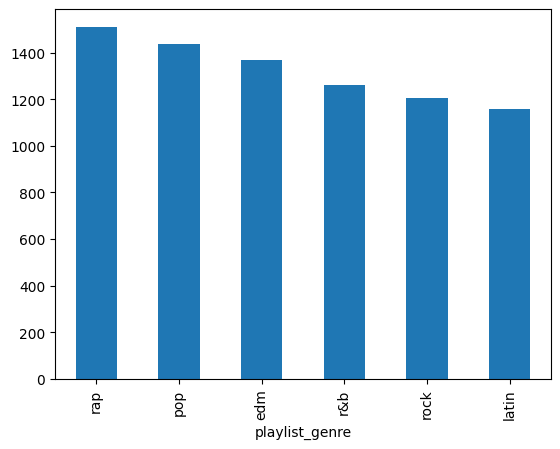

In [68]:
# playlist_genre can be considered as our classification label
print(df.playlist_genre.unique())
# plot labels distribution
df['playlist_genre'].value_counts().plot(kind='bar')

In [69]:
# We keep only **two genres** to turn this into a binary classification problem.  

SEED = 17

GENRE_A = 'rap'
GENRE_B = 'edm'

# Filter and subsample each genre
df_a = df[df['playlist_genre'] == GENRE_A]
df_b = df[df['playlist_genre'] == GENRE_B]

# Concatenate and shuffle
df_binary = pd.concat([df_a, df_b]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print('Dataset shape:', df_binary.shape)
print(df_binary['playlist_genre'].value_counts())

Dataset shape: (2879, 23)
playlist_genre
rap    1512
edm    1367
Name: count, dtype: int64


In [64]:
# isolate the label colum and encode them in binary form

df_labels = df_binary['playlist_genre']
# Encode target: GENRE_A → 0, GENRE_B → 1
le = LabelEncoder()
y = le.fit_transform(df_labels)
print('Classes:', le.classes_, '→ labels:', [0, 1])

y

Classes: ['edm' 'rap'] → labels: [0, 1]


array([0, 1, 0, ..., 1, 0, 0], shape=(2879,))

In [65]:
# select only numerical features 
df_features = df_binary[['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']]
    
df_features

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.595,0.913,10,-3.428,0,0.0884,0.04350,0.000000,0.2590,0.762,128.021,234453
1,0.896,0.715,2,-3.370,1,0.0544,0.19500,0.000000,0.0678,0.513,128.010,298394
2,0.651,0.766,5,-5.526,1,0.0301,0.03750,0.000879,0.0942,0.199,97.926,221569
3,0.595,0.285,11,-14.360,0,0.0371,0.97300,0.946000,0.1460,0.305,130.021,118154
4,0.750,0.420,8,-9.747,1,0.0386,0.06510,0.800000,0.0778,0.364,131.985,214549
...,...,...,...,...,...,...,...,...,...,...,...,...
2874,0.694,0.629,6,-8.928,1,0.1430,0.08940,0.000004,0.1310,0.618,140.053,209514
2875,0.315,0.770,5,-3.913,0,0.0929,0.45400,0.000000,0.1220,0.433,140.095,220853
2876,0.718,0.776,8,-5.418,1,0.2400,0.11200,0.002430,0.1440,0.410,91.158,145085
2877,0.610,0.645,1,-5.737,1,0.0648,0.30700,0.000000,0.1980,0.400,126.077,171429


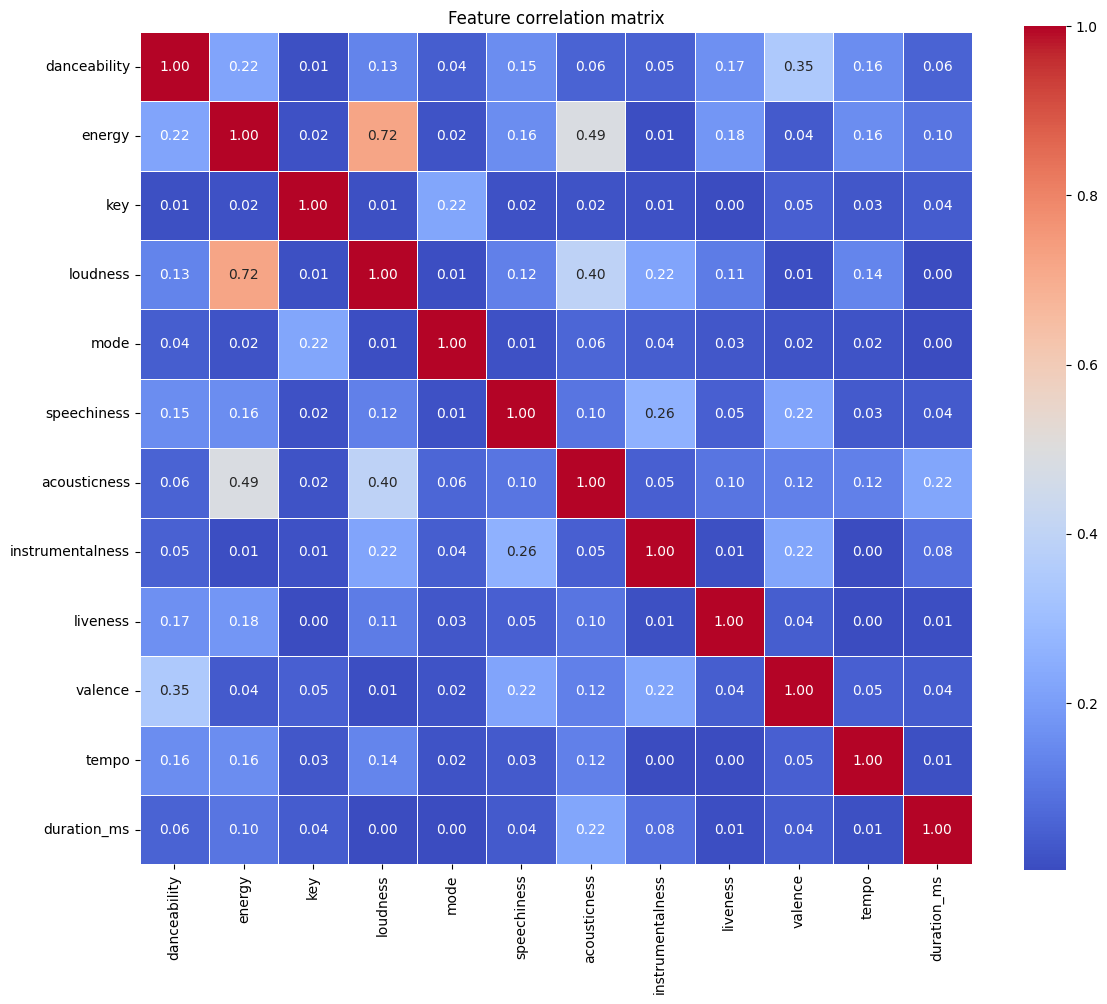

In [70]:
# check for multicollinear features
corr_matrix = df_features.corr().abs()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.show()

In [71]:
# From the graphical correlation matrix -> High correlation between loudness and energy -> create a new feature as their sum (or any other linear combination to remove the multicollinearity)
# We can also consider a threshold over which the two features are fused together

df_features['loud_ener'] = df_features['loudness'] + df_features['energy']

df_features = df_features.drop(columns=['energy', 'loudness'])

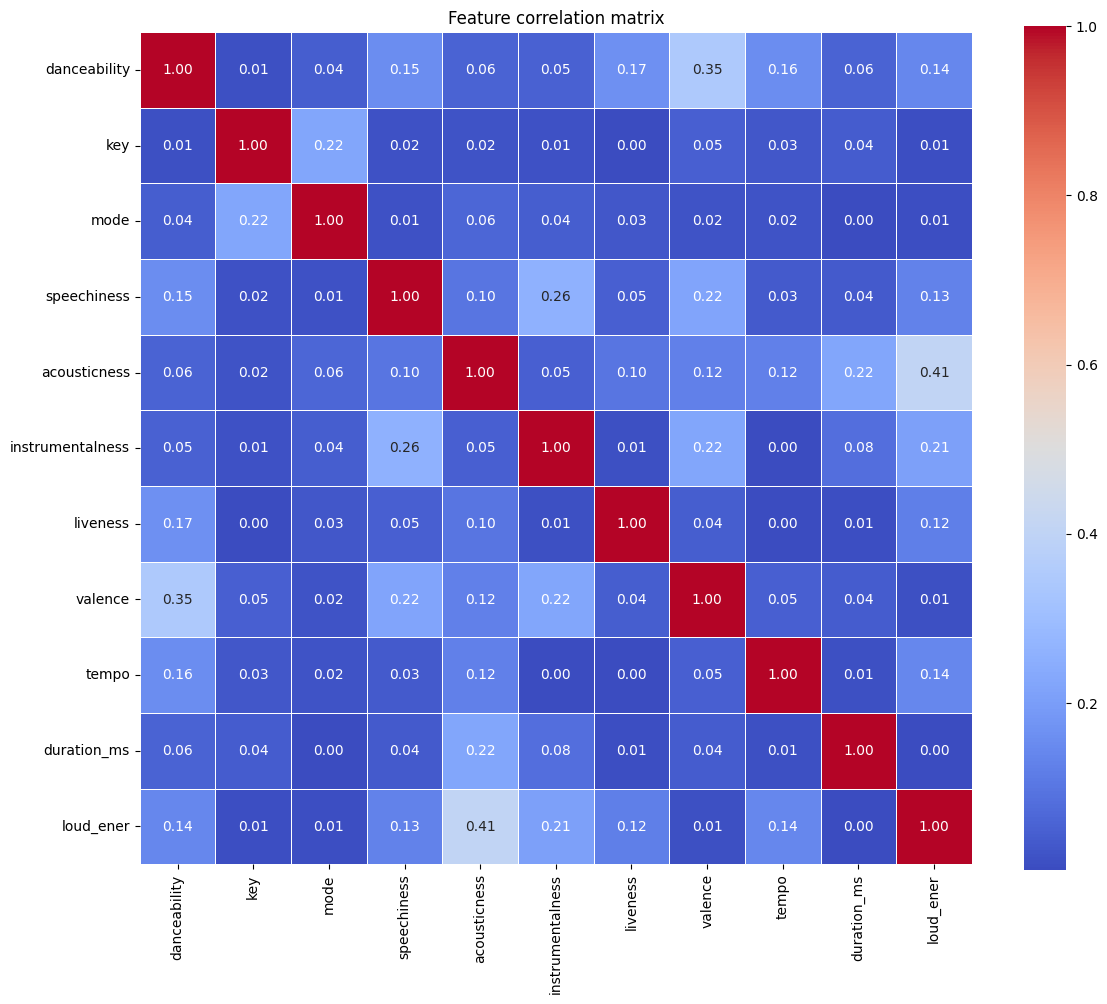

In [72]:
# check for correlation matrix after features removal
corr_matrix = df_features.corr().abs()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.show()

In [ ]:
# filer-based feature selection w/ fisher_score

K_BEST = 8    # number of features to keep

selector = SelectKBest(score_func=fisher_score.fisher_score, k=K_BEST)
df_filter = selector.fit_transform(df_features, y)

# Get selected feature names
selected_mask = selector.get_support()
selected_features = df_features.columns[selected_mask].tolist()
print(f'Top {K_BEST} features selected:', selected_features)

print(df_filter.shape)
print(df_filter[0])

Top 8 features selected: ['danceability', 'energy', 'key', 'mode', 'acousticness', 'valence', 'tempo', 'duration_ms']
(2879, 8)
[5.95000e-01 9.13000e-01 1.00000e+01 0.00000e+00 4.35000e-02 7.62000e-01
 1.28021e+02 2.34453e+05]


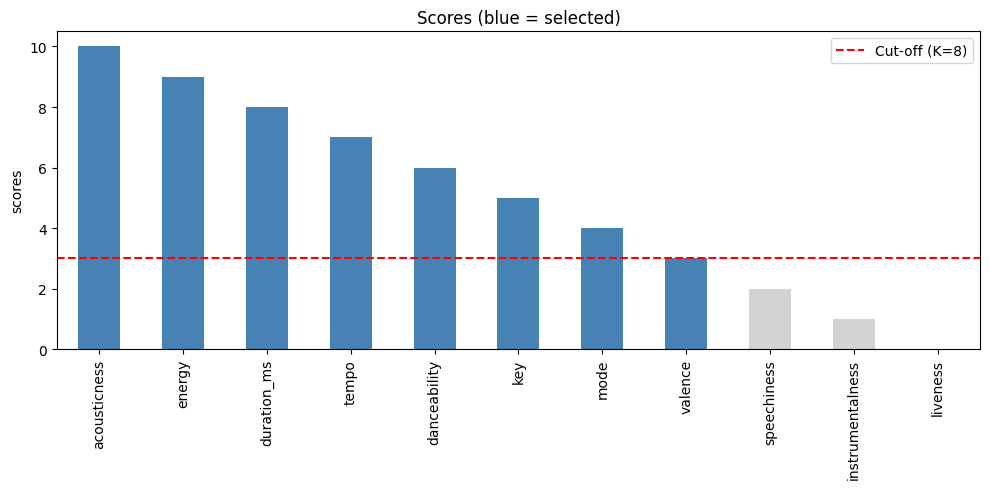

In [51]:
# Plot scores for all remaining features
scores = pd.Series(selector.scores_, index=df_features.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
scores.plot(kind='bar', color=['steelblue' if f in selected_features else 'lightgrey'
                                for f in scores.index])
plt.axhline(scores.iloc[K_BEST - 1], color='red', linestyle='--', label=f'Cut-off (K={K_BEST})')
plt.title('Scores (blue = selected)')
plt.ylabel('scores')
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
# Build final feature DataFrame from selected columns
X = pd.DataFrame(df_filter, columns=selected_features)
print('Final feature matrix shape:', X.shape)
X.head(3)

Final feature matrix shape: (2879, 8)


,danceability,energy,key,mode,acousticness,valence,tempo,duration_ms
0,0.595,0.913,10.0,0.0,0.0435,0.762,128.021,234453.0
1,0.896,0.715,2.0,1.0,0.1950,0.513,128.010,298394.0
2,0.651,0.766,5.0,1.0,0.0375,0.199,97.926,221569.0


In [53]:
# perform a train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,                         # Takes 20% of the data
    stratify=y,   # Ensures 'label' proportions are kept
    random_state=SEED,                      # For reproducibility
)

In [54]:
# perform standardization over the numerical features of the dataset
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on training data only
X_test_sc  = scaler.transform(X_test)        # apply same transform to test

In [55]:
# Decision Tree classifier
dt = DecisionTreeClassifier(max_depth=5, random_state=SEED)
dt.fit(X_train_sc, y_train)
y_pred = dt.predict(X_test_sc)

In [56]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

         edm       0.80      0.81      0.81       273
         rap       0.83      0.82      0.82       303

    accuracy                           0.81       576
   macro avg       0.81      0.81      0.81       576
weighted avg       0.81      0.81      0.81       576



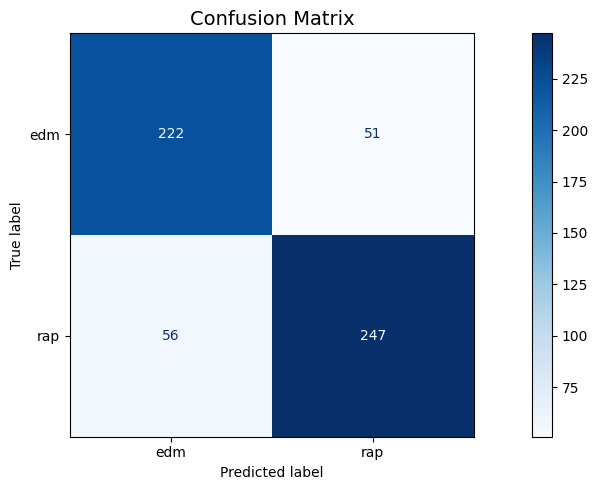

In [57]:
fig, axes = plt.subplots(figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=le.classes_,
    cmap='Blues',
    ax=axes
)

plt.title('Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

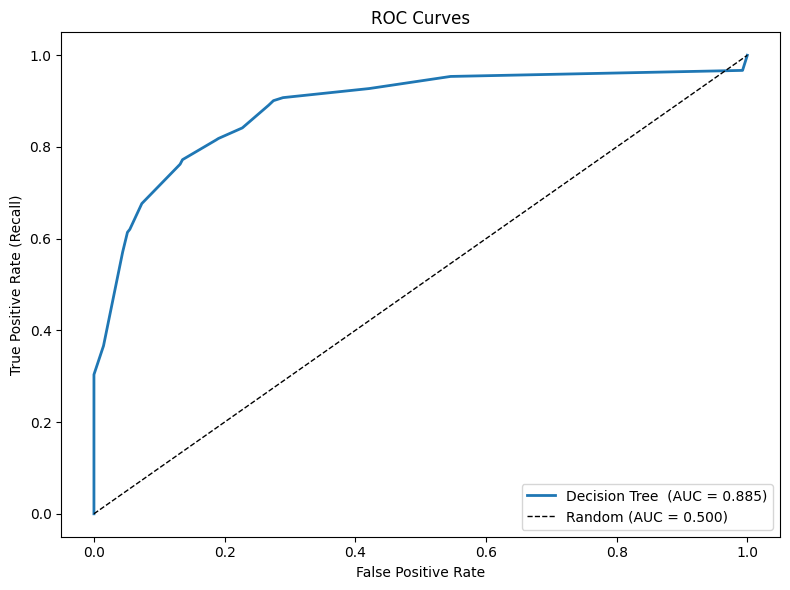

In [58]:
# calculate auc and roc curve

def plot_roc(name, model, X_test_sc, y_test):
    fig, ax = plt.subplots(figsize=(8, 6))

    # Probability for the positive class
    y_score = model.predict_proba(X_test_sc)[:, 1]

    # Compute ROC points and AUC
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)

    ax.plot(fpr, tpr, lw=2, label=f'{name}  (AUC = {auc:.3f})')

    # Random classifier baseline
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.500)')

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate (Recall)')
    ax.set_title('ROC Curves')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

plot_roc('Decision Tree', dt, X_test_sc, y_test)